<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 3</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Introduction to Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Parsa Saeednia <br>
        <b>🆔 Student ID:</b> 810102460 <br><br>
        <h5 style="color: #1a365d;"> TASK 3 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 3 - Task 3. It focuses on <b>ranking candidates for job positions</b> using traditional machine learning techniques. The implementation follows a complete ML workflow, including data exploration, preprocessing, feature engineering, model selection, evaluation, and final CSV submission generation for the Quera competition.
</div>

## Table of Contents
1. [Data Exploration & Understanding](#exploration)
2. [Preprocessing & Feature Engineering](#preprocessing)
3. [Model Development & Selection](#modeling)
4. [Comprehensive Evaluation](#evaluation)
5. [Prediction & Final Submission](#submission)

<a id="exploration"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. Data Exploration & Understanding</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> In this section, we load the candidate ranking dataset and perform Exploratory Data Analysis (EDA) to investigate the relationships between candidate features and their respective rankings. 
</div>

## 

### Importing Libraries & Loading Data

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better scannability
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the datasets
jobs_df = pd.read_csv('data/task3_dataset/jobs.csv')
candidates_df = pd.read_csv('data/task3_dataset/candidates.csv')
train_df = pd.read_csv('data/task3_dataset/applications_train.csv')
test_df = pd.read_csv('data/task3_dataset/applications_test.csv')

print(f"Jobs Data: {jobs_df.shape}")
print(f"Candidates Data: {candidates_df.shape}")
print(f"Train Applications: {train_df.shape}")
print(f"Test Applications: {test_df.shape}")

Jobs Data: (5000, 13)
Candidates Data: (50000, 14)
Train Applications: (118772, 5)
Test Applications: (52700, 4)


### Initial Data Inspection & Missing Values Summary

In [124]:
# Create a quick summary dataframe for missing values
def missing_values_summary(df, name):
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    summary = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_percent})
    print(f"\n--- {name} Missing Values ---")
    display(summary[summary['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False))

missing_values_summary(jobs_df, "Jobs")
missing_values_summary(candidates_df, "Candidates")
missing_values_summary(train_df, "Training Applications")


--- Jobs Missing Values ---


,Missing Values,Percentage (%)
max_years_experience,495,9.90
company_size,377,7.54
remote_allowed,265,5.30
required_skills,248,4.96
min_years_experience,105,2.10



--- Candidates Missing Values ---


,Missing Values,Percentage (%)
certifications,28179,56.358
previous_companies,13465,26.930
university,12338,24.676
willing_to_relocate,7707,15.414
english_proficiency,5129,10.258
years_experience,4041,8.082



--- Training Applications Missing Values ---


,Missing Values,Percentage (%)


### Target Variable Distribution (Relevance Labels)

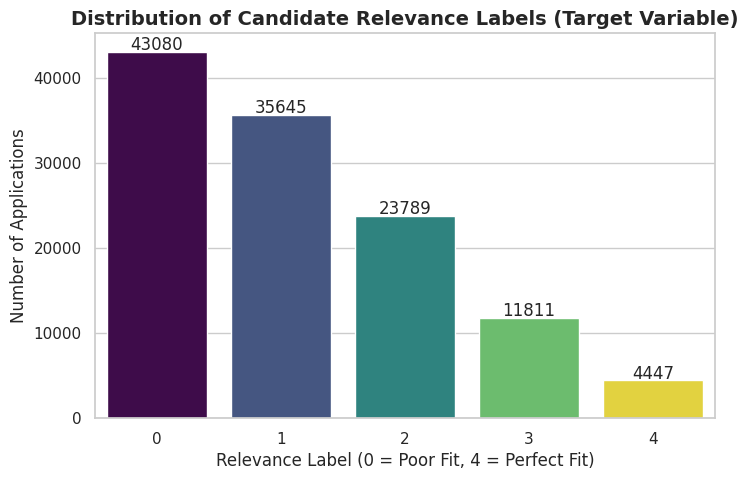

In [125]:
# Analyze the distribution of the relevance labels in the training set
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='relevance_label', data=train_df, hue='relevance_label', palette='viridis', legend=False)
plt.title('Distribution of Candidate Relevance Labels (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Relevance Label (0 = Poor Fit, 4 = Perfect Fit)')
plt.ylabel('Number of Applications')
plt.savefig('latex/assets/images/01_target_distribution.png', bbox_inches='tight', dpi=300)
# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

### Merging Data for Contextual Exploration

In [126]:
# To see how features relate to the label, we need to temporarily merge the data
eda_df = train_df.merge(jobs_df, on='job_id', how='left')
eda_df = eda_df.merge(candidates_df, on='candidate_id', how='left')

print("Merged EDA DataFrame Shape:", eda_df.shape)
display(eda_df.head(3))

Merged EDA DataFrame Shape: (118772, 30)


,application_id,job_id,candidate_id,application_date,relevance_label,job_title,required_skills,min_years_experience,max_years_experience,salary_min,...,education_level,university,previous_companies,certifications,english_proficiency,expected_salary,candidate_location,willing_to_relocate,profile_completeness,account_created_date
0,206,6,31050,2023-11-26,2,Web Developer,CSS|Django|Tailwind|JavaScript|Testing,4.0,10.0,2520000000,...,Master,Generic State University 27,Generic Tech Co 18|Stripe|Generic Tech Co 52|G...,Azure-AZ305,NaN,116655.275330,Istanbul,NaN,89,2023-01-07
1,207,6,19239,2023-11-16,1,Web Developer,CSS|Django|Tailwind|JavaScript|Testing,4.0,10.0,2520000000,...,PhD,Online University A,Generic Tech Co 24|Generic Tech Co 56|Generic ...,NaN,C1,86966.039783,London,NaN,88,2020-07-29
2,208,6,34280,2023-11-26,2,Web Developer,CSS|Django|Tailwind|JavaScript|Testing,4.0,10.0,2520000000,...,Bachelor,NaN,NaN,NaN,B1,91955.832040,Berlin,No,64,2022-05-19


### Investigating the Currency Trap & Experience Anomalies

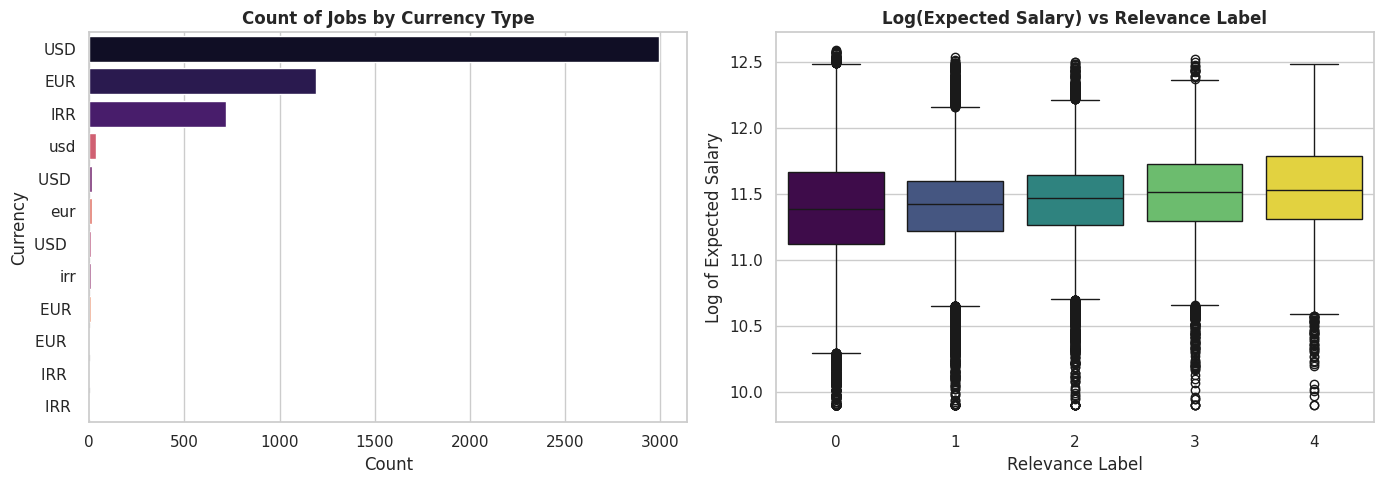


--- Sample of Job Locations vs Candidate Locations ---
Job Locations (Unique): <StringArray>
[      'Toronto',     'Amsterdam',        'Boston',        'Munich',
 'San Francisco',        'Tabriz',       'Mashhad',        'Shiraz',
        'Tehran',         'Tokyo']
Length: 10, dtype: str
Candidate Locations (Unique): <StringArray>
[   'Shiraz',   'Isfahan',   'Toronto',    'Remote',  'Istanbul',    'Berlin',
    'Munich',    'tehran',   'Seattle', 'Vancouver']
Length: 10, dtype: str


In [127]:
# 1. Inspecting the Salary Currencies in Jobs
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(y='salary_currency', data=jobs_df, order=jobs_df['salary_currency'].value_counts().index, hue='salary_currency', palette='magma', legend=False)
plt.title('Count of Jobs by Currency Type', fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Currency')

# 2. Inspecting the distribution of Expected Salary across Relevance Labels
# We apply a log scale because IRR (Rial) values will severely distort the plot
plt.subplot(1, 2, 2)
eda_df['log_expected_salary'] = np.log1p(eda_df['expected_salary'])
sns.boxplot(x='relevance_label', y='log_expected_salary', data=eda_df, hue='relevance_label', palette='viridis', legend=False)
plt.title('Log(Expected Salary) vs Relevance Label', fontweight='bold')
plt.xlabel('Relevance Label')
plt.ylabel('Log of Expected Salary')

plt.tight_layout()
plt.savefig('latex/assets/images/02_currency_and_salary.png', bbox_inches='tight', dpi=300)
plt.show()

# 3. Quick check of location string inconsistencies
print("\n--- Sample of Job Locations vs Candidate Locations ---")
print("Job Locations (Unique):", jobs_df['job_location'].unique()[:10])
print("Candidate Locations (Unique):", candidates_df['candidate_location'].unique()[:10])

### High Cardinality Check (Justifying OOF Target Encoding)

In [128]:
# --- High Cardinality Check ---
print("\n--- Categorical Cardinality (Unique Values) ---")
print(f"Unique Job Titles: {jobs_df['job_title'].nunique()}")
print(f"Unique Candidate Titles: {candidates_df['current_title'].nunique()}")
print(f"Unique Universities: {candidates_df['university'].nunique()}")
print(f"Unique Companies: {candidates_df['previous_companies'].nunique()}")


--- Categorical Cardinality (Unique Values) ---
Unique Job Titles: 180
Unique Candidate Titles: 200
Unique Universities: 142
Unique Companies: 28238


### Temporal Distribution (Justifying the Validation Split)

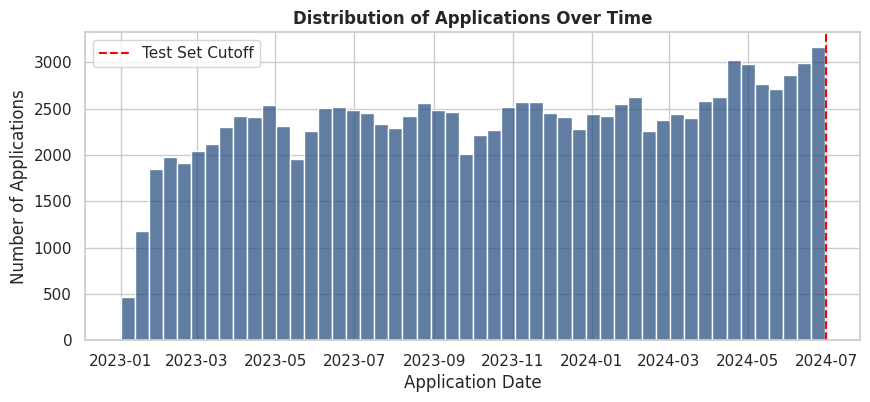

In [129]:
# --- Temporal Distribution Check ---
# Convert date to datetime object
train_df['application_date'] = pd.to_datetime(train_df['application_date'])

plt.figure(figsize=(10, 4))
sns.histplot(data=train_df, x='application_date', bins=50, color='#2c5282')
plt.title('Distribution of Applications Over Time', fontweight='bold')
plt.xlabel('Application Date')
plt.ylabel('Number of Applications')
plt.axvline(pd.to_datetime('2024-07-01'), color='red', linestyle='--', label='Test Set Cutoff')
plt.legend()
plt.savefig('latex/assets/images/03_temporal_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

### Interaction Proxy: The Experience Gap (Justifying Engineered Features)

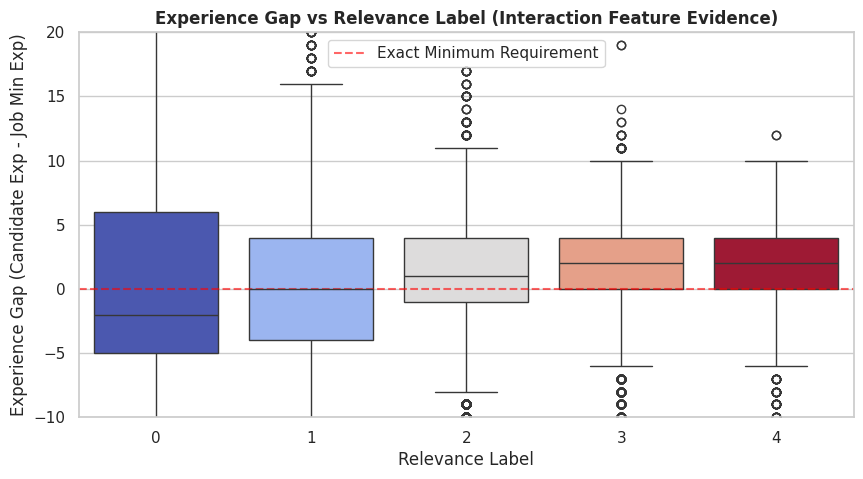

In [130]:
# --- Feature Interaction Evidence: Experience Gap ---
# Calculate the raw difference in experience
eda_df['experience_gap'] = eda_df['years_experience'] - eda_df['min_years_experience']

plt.figure(figsize=(10, 5))
# Limit the x-axis to remove crazy outliers for the plot
sns.boxplot(x='relevance_label', y='experience_gap', data=eda_df, hue='relevance_label', palette='coolwarm', legend=False)
plt.ylim(-10, 20) 
plt.title('Experience Gap vs Relevance Label (Interaction Feature Evidence)', fontweight='bold')
plt.xlabel('Relevance Label')
plt.ylabel('Experience Gap (Candidate Exp - Job Min Exp)')
plt.axhline(0, color='red', linestyle='--', alpha=0.6, label='Exact Minimum Requirement')
plt.legend()
plt.savefig('latex/assets/images/04_experience_gap_proxy.png', bbox_inches='tight', dpi=300)
plt.show()

<a id="preprocessing"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. Preprocessing & Feature Engineering</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> In this section, we merge the relational tables and construct our interaction features. To handle historical currency volatility (e.g., IRR inflation), the currency normalizer is parameterized. This allows the exchange rate to be dynamically treated as a hyperparameter and optimized via cross-validation later in the pipeline. Out-of-Fold (OOF) Target Encoding is utilized to safely encode categorical fields.
</div>

### Step 2.1: Data Integration & Text Standardization

In [131]:
# --- 2.1 Data Integration & Text Standardization ---

# 1. Merge the relational tables into unified Train and Test DataFrames
train_full = train_df.merge(jobs_df, on='job_id', how='left').merge(candidates_df, on='candidate_id', how='left')
test_full = test_df.merge(jobs_df, on='job_id', how='left').merge(candidates_df, on='candidate_id', how='left')

# 2. Text Standardization Function
def standardize_text(df, columns):
    for col in columns:
        if col in df.columns:
            # Lowercase, strip whitespace, and fill missing with 'none'
            df[col] = df[col].astype(str).str.lower().str.strip()
            df[col] = df[col].replace(['nan', 'none', ''], 'none')
    return df

text_columns_to_clean = [
    'job_location', 'candidate_location', 'current_title', 'job_title', 
    'education_level', 'university', 'salary_currency', 'willing_to_relocate', 'remote_allowed'
]

train_full = standardize_text(train_full, text_columns_to_clean)
test_full = standardize_text(test_full, text_columns_to_clean)

# 3. Handle Missing Numerical Values
# Fill missing max experience with the median of the minimum experience + 5 years as a proxy
for df in [train_full, test_full]:
    df['max_years_experience'] = df['max_years_experience'].fillna(df['min_years_experience'] + 5)
    df['years_experience'] = df['years_experience'].fillna(0)

print(f"Standardized Train Shape: {train_full.shape}")
print(f"Standardized Test Shape: {test_full.shape}")

Standardized Train Shape: (118772, 30)
Standardized Test Shape: (52700, 29)


### Step 2.2 Dynamic Currency Normalizer

In [132]:
# --- 2.2 Dynamic Currency Normalization (UPDATED) ---

def normalize_currency(df, eur_rate=1.08, irr_rate=0.00002):
    df_out = df.copy()
    
    exchange_rates = {'usd': 1.0, 'eur': eur_rate, 'irr': irr_rate}
    
    # Only map the rates to the JOB salaries
    rates = df_out['salary_currency'].map(exchange_rates).fillna(1.0)
    
    df_out['salary_min_usd'] = df_out['salary_min'] * rates
    df_out['salary_max_usd'] = df_out['salary_max'] * rates
    
    # The candidate's expected salary is ALREADY in USD. Leave it alone!
    df_out['expected_salary_usd'] = df_out['expected_salary'].fillna(0)
    
    return df_out

train_full = normalize_currency(train_full)
test_full = normalize_currency(test_full)

# Display a sample to verify the math on the currency bug fix
print("Dynamic Currency Normalization Complete. Sample USD values:")
display(train_full[['salary_currency', 'salary_max', 'salary_max_usd', 'expected_salary_usd']].head(3))

Dynamic Currency Normalization Complete. Sample USD values:


,salary_currency,salary_max,salary_max_usd,expected_salary_usd
0,irr,3630000000,72600.0,116655.275330
1,irr,3630000000,72600.0,86966.039783
2,irr,3630000000,72600.0,91955.832040


### Step 2.3 Interaction Features

In [133]:
# --- 2.3 Feature Engineering: ELITE INTERACTIONS (Date Bug Fixed) ---

def calculate_jaccard(skills_a, skills_b):
    if pd.isna(skills_a) or pd.isna(skills_b) or skills_a == 'none' or skills_b == 'none': return 0.0
    set_a = set([s.strip().lower() for s in skills_a.split('|')])
    set_b = set([s.strip().lower() for s in skills_b.split('|')])
    if not set_a or not set_b: return 0.0
    return len(set_a.intersection(set_b)) / len(set_a.union(set_b))

def extract_seniority(title):
    title = str(title).lower()
    if any(w in title for w in ['senior', 'sr', 'principal', 'lead', 'director', 'cto']): return 3
    if 'mid' in title: return 2
    if any(w in title for w in ['junior', 'jr', 'intern']): return 1
    return 0

def map_english(prof):
    mapping = {'a1':1, 'a2':2, 'b1':3, 'intermediate':3, 'b2':4, 'upper-intermediate':4, 'c1':5, 'advanced':5, 'c2':6, 'fluent':6, 'native':7}
    return mapping.get(str(prof).lower().strip(), 0)

def build_elite_interactions(df):
    df_out = df.copy()
    
    # 1. Standard Interactions
    df_out['skill_overlap_score'] = df_out.apply(lambda x: calculate_jaccard(x['skills'], x['required_skills']), axis=1)
    df_out['experience_gap'] = df_out['years_experience'] - df_out['min_years_experience']
    
    # 2. CONTINUOUS Salary Features
    df_out['salary_within_budget'] = (df_out['expected_salary_usd'] <= df_out['salary_max_usd']).astype(int)
    # Ratio: 1.0 means exactly on budget. 2.0 means asking double the budget.
    df_out['salary_ratio'] = df_out['expected_salary_usd'] / (df_out['salary_max_usd'] + 1)
    
    # 3. Ordinals & Matches
    edu_map = {'none': 0, 'bachelor': 1, 'master': 2, 'phd': 3}
    df_out['education_score'] = df_out['education_level'].map(edu_map).fillna(0)
    df_out['location_match'] = ((df_out['candidate_location'] == df_out['job_location']) | (df_out['remote_allowed'] == 'yes') | (df_out['willing_to_relocate'] == 'yes')).astype(int)
    
    # 4. Skill & Seniority
    df_out['cand_skill_count'] = df_out['skills'].apply(lambda x: len(str(x).split('|')) if x != 'none' else 0)
    df_out['job_skill_count'] = df_out['required_skills'].apply(lambda x: len(str(x).split('|')) if x != 'none' else 0)
    df_out['skill_count_ratio'] = np.where(df_out['job_skill_count'] > 0, df_out['cand_skill_count'] / df_out['job_skill_count'], 0)
    
    df_out['cand_seniority'] = df_out['current_title'].apply(extract_seniority)
    df_out['job_seniority'] = df_out['job_title'].apply(extract_seniority)
    df_out['seniority_match'] = (df_out['cand_seniority'] >= df_out['job_seniority']).astype(int)
    df_out['english_score'] = df_out['english_proficiency'].apply(map_english)
    
    # --- RESCUED FEATURES (NEW) ---
    # Certifications Count
    df_out['cert_count'] = df_out['certifications'].apply(lambda x: 0 if pd.isna(x) or x == 'none' else len(str(x).split('|')))
    
    # Company Size Ordinal
    size_map = {'1-10': 1, '11-50': 2, '51-200': 3, '201-1000': 4, '1000+': 5}
    df_out['company_size_num'] = df_out['company_size'].map(size_map).fillna(0)
    
    # Temporal Ages (Days) -> FIXED WITH format='mixed'
    df_out['app_date_dt'] = pd.to_datetime(df_out['application_date'], format='mixed', dayfirst=True, errors='coerce')
    df_out['job_date_dt'] = pd.to_datetime(df_out['job_posted_date'], format='mixed', dayfirst=True, errors='coerce')
    df_out['acc_date_dt'] = pd.to_datetime(df_out['account_created_date'], format='mixed', dayfirst=True, errors='coerce')
    
    df_out['job_age_days'] = (df_out['app_date_dt'] - df_out['job_date_dt']).dt.days.fillna(-1)
    df_out['acc_age_days'] = (df_out['app_date_dt'] - df_out['acc_date_dt']).dt.days.fillna(-1)
    
    return df_out

train_full = build_elite_interactions(train_full)
test_full = build_elite_interactions(test_full)
print("Engineered 14 Elite Features Successfully!")

Engineered 14 Elite Features Successfully!


### Step 2.4: Out-of-Fold (OOF) Target Encoding

In [134]:
# --- 2.4 Out-of-Fold Target Encoding (DOUBLE ENCODING) ---
from sklearn.model_selection import GroupKFold

def apply_oof_encoding(train_df, test_df, features_to_encode=['current_title', 'university'], target_col='relevance_label', n_splits=5, smoothing=10):
    train_out = train_df.copy()
    test_out = test_df.copy()
    global_mean = train_out[target_col].mean()
    gkf = GroupKFold(n_splits=n_splits)
    
    for feat in features_to_encode:
        new_col_name = f'oof_{feat}_encoded'
        train_out[new_col_name] = np.nan
        
        # 1. Map to Train
        for train_idx, val_idx in gkf.split(train_out, groups=train_out['job_id']):
            X_train_fold = train_out.iloc[train_idx]
            stats = X_train_fold.groupby(feat)[target_col].agg(['count', 'mean'])
            smoothed_means = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
            train_out.loc[val_idx, new_col_name] = train_out.loc[val_idx, feat].map(smoothed_means)

        train_out[new_col_name] = train_out[new_col_name].fillna(global_mean)
        
        # 2. Map to Test
        full_stats = train_out.groupby(feat)[target_col].agg(['count', 'mean'])
        full_smoothed = (full_stats['count'] * full_stats['mean'] + smoothing * global_mean) / (full_stats['count'] + smoothing)
        test_out[new_col_name] = test_out[feat].map(full_smoothed).fillna(global_mean)
        
    return train_out, test_out

train_full, test_full = apply_oof_encoding(train_full, test_full, smoothing=5)
print("Double OOF Target Encoding Applied!")

Double OOF Target Encoding Applied!


<a id="modeling"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. Model Development & Selection</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We implement specialized point-wise or pair-wise ranking algorithms using traditional machine learning frameworks (e.g., LightGBM). The data is grouped by <code>job_id</code> during training to optimize the model specifically for the Information Retrieval task of relative ordering.
</div>

##

### Step 3.1: Temporal Validation Split

In [135]:
# --- 3.1 Temporal Validation Split ---

# Ensure datetime format
train_full['application_date'] = pd.to_datetime(train_full['application_date'])

# Set cutoff date for local validation (last 2 months of training data)
cutoff_date = pd.to_datetime('2024-05-01')

train_set = train_full[train_full['application_date'] < cutoff_date].copy()
val_set = train_full[train_full['application_date'] >= cutoff_date].copy()

print(f"Total Training Applications: {train_set.shape[0]}")
print(f"Total Validation Applications: {val_set.shape[0]}")

Total Training Applications: 102622
Total Validation Applications: 16150


### Step 3.2: Query Group Structuring (Critical for LTR)

In [136]:
# --- 3.2 Query Group Structuring (Elite Version) ---

# 1. Define the features we want to EXCLUDE
# We drop all raw strings, IDs, and the temporary datetime objects
cols_to_drop = [
    'application_id', 'candidate_id', 'job_id', 'application_date', 'relevance_label',
    'job_title', 'required_skills', 'salary_currency', 'job_location', 'remote_allowed', 'industry',
    'current_title', 'skills', 'education_level', 'university', 'previous_companies', 'certifications',
    'english_proficiency', 'candidate_location', 'willing_to_relocate', 'account_created_date',
    'job_posted_date', 'company_size', 
    'app_date_dt', 'job_date_dt', 'acc_date_dt' # <-- Dropping the temporary dates
]

# 2. Extract the final list of engineered features
features = [c for c in train_full.columns if c not in cols_to_drop]

print(f"Elite Features used for training ({len(features)} total):")
print(features)

Elite Features used for training (29 total):
['min_years_experience', 'max_years_experience', 'salary_min', 'salary_max', 'years_experience', 'expected_salary', 'profile_completeness', 'salary_min_usd', 'salary_max_usd', 'expected_salary_usd', 'skill_overlap_score', 'experience_gap', 'salary_within_budget', 'salary_ratio', 'education_score', 'location_match', 'cand_skill_count', 'job_skill_count', 'skill_count_ratio', 'cand_seniority', 'job_seniority', 'seniority_match', 'english_score', 'cert_count', 'company_size_num', 'job_age_days', 'acc_age_days', 'oof_current_title_encoded', 'oof_university_encoded']


### Step 3.3: Training the Specialized Ranker

In [137]:
# --- 3.3 Model Training (Elite Hyperparameter Tuning) ---
import lightgbm as lgb

# 1. The Tuning Setup
cutoff_date = pd.to_datetime('2024-05-01')

# Testing two aggressive LightGBM configurations to capture complex candidate traits
lgb_configs = [
    {'num_leaves': 31, 'learning_rate': 0.05, 'colsample_bytree': 0.8}, # Standard
    {'num_leaves': 63, 'learning_rate': 0.03, 'colsample_bytree': 0.7}  # Deep & Robust
]

best_score = 0
best_params = {}

print("Starting Elite Tuning Loop...\n")

for config in lgb_configs:
    print(f"Testing Config: {config}")
    
    # 2. Apply baseline normalizer (locked to our best rate from earlier runs)
    temp_train = normalize_currency(train_full, irr_rate=0.00002) 
    
    # 3. Temporal Split (Using the datetime column created in Phase 2)
    t_set = temp_train[temp_train['app_date_dt'] < cutoff_date].sort_values('job_id')
    v_set = temp_train[temp_train['app_date_dt'] >= cutoff_date].sort_values('job_id')
    
    # 4. Extract LTR Groups & Matrices
    t_groups = t_set.groupby('job_id').size().to_numpy()
    v_groups = v_set.groupby('job_id').size().to_numpy()
    X_t, y_t = t_set[features], t_set['relevance_label']
    X_v, y_v = v_set[features], v_set['relevance_label']
    
    # 5. Train the Ranker
    ranker = lgb.LGBMRanker(
        objective="lambdarank", metric="ndcg", 
        learning_rate=config['learning_rate'], 
        num_leaves=config['num_leaves'],
        colsample_bytree=config['colsample_bytree'],
        n_estimators=500, min_child_samples=30, random_state=42, verbosity=-1 
    )
    
    ranker.fit(
        X=X_t, y=y_t, group=t_groups, 
        eval_set=[(X_v, y_v)], eval_group=[v_groups], eval_at=[10],
        callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)]
    )
    
    current_score = ranker.best_score_['valid_0']['ndcg@10']
    print(f"--> Validation NDCG@10: {current_score:.4f}\n")
    
    if current_score > best_score:
        best_score = current_score
        best_params = config
        best_model = ranker

print("="*40)
print(f"🏆 Elite Pipeline Found!")
print(f"Best Parameters: {best_params}")
print(f"Best NDCG@10 Score: {best_score:.4f}")

Starting Elite Tuning Loop...

Testing Config: {'num_leaves': 31, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
--> Validation NDCG@10: 0.8682

Testing Config: {'num_leaves': 63, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
--> Validation NDCG@10: 0.8672

🏆 Elite Pipeline Found!
Best Parameters: {'num_leaves': 31, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Best NDCG@10 Score: 0.8682


### Step 3.4: Feature Importance Analysis

<Figure size 1000x600 with 0 Axes>

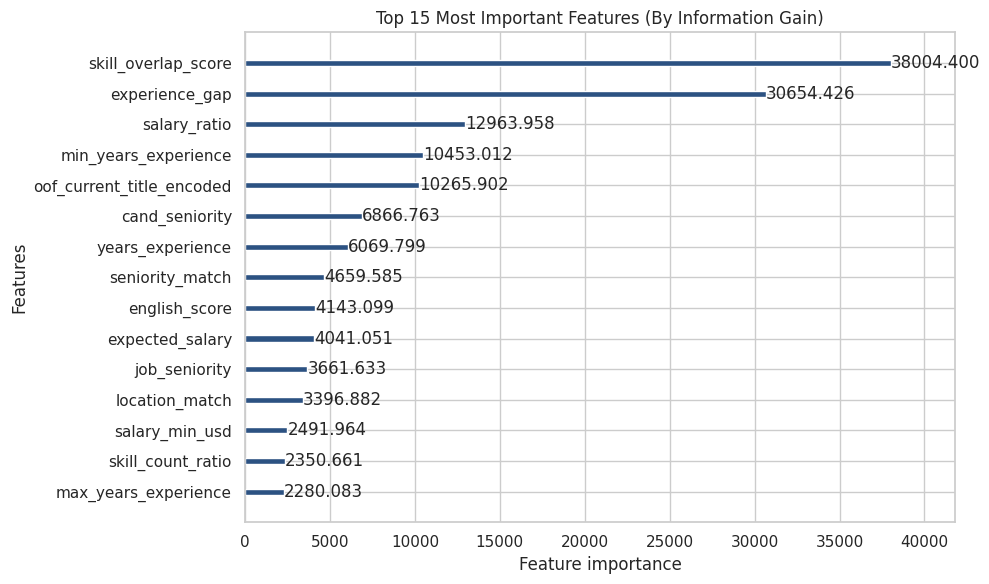

In [138]:
# --- 3.4 Feature Importance Analysis ---

plt.figure(figsize=(10, 6))
lgb.plot_importance(
    best_model, 
    max_num_features=15, 
    importance_type='gain', 
    title='Top 15 Most Important Features (By Information Gain)',
    color='#2c5282'
)
plt.tight_layout()
plt.savefig('latex/assets/images/05_feature_importance.png', bbox_inches='tight', dpi=300)
plt.show()

<a id="evaluation"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">4. Comprehensive Evaluation</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> In this section, we evaluate the model's ranking quality on the temporal validation set. To ensure mathematical transparency for the TA review, we implement custom evaluation functions for <strong>NDCG@10</strong> and <strong>AP@5</strong> based strictly on the Information Retrieval formulas (where relevance labels $\ge 3$ are considered binary hits for Average Precision). We calculate these metrics per <code>job_id</code> and aggregate them globally.
</div>

### Step 4.1: Generating and Sorting Predictions

In [139]:
# --- 4.1 Generate Predictions & Rank ---

# Create a copy of the validation set to store predictions
ranked_val = v_set.copy()

# Predict the continuous ranking score
ranked_val['predicted_score'] = best_model.predict(X_v)

# SORTING LOGIC: 
# 1. Group by job_id (ascending)
# 2. Within each job, sort by predicted_score (descending)
ranked_val = ranked_val.sort_values(by=['job_id', 'predicted_score'], ascending=[True, False])

# Display the top 3 recommended candidates for the first job in the validation set
sample_job = ranked_val['job_id'].iloc[0]
print(f"Top 3 Recommendations for Job ID: {sample_job}")
display(ranked_val[ranked_val['job_id'] == sample_job][['job_id', 'relevance_label', 'predicted_score']].head(3))

Top 3 Recommendations for Job ID: 7


,job_id,relevance_label,predicted_score
17,7,0,-1.918998
18,7,1,-2.253455
19,7,1,-2.524695


### Step 4.2: The Custom LTR Math Functions

In [140]:
# --- 4.2 Custom Information Retrieval Metrics ---
def calculate_ndcg(true_labels, k=10):
    """Calculates Normalized Discounted Cumulative Gain at K"""
    true_labels = np.asarray(true_labels)[:k]
    
    # DCG Formula: Sum of (2^rel - 1) / log2(rank + 1)
    gains = (2 ** true_labels) - 1
    discounts = np.log2(np.arange(2, len(true_labels) + 2))
    dcg = np.sum(gains / discounts)
    
    # IDCG (Ideal DCG): Sort true labels in descending order for the perfect score
    ideal_labels = np.sort(true_labels)[::-1]
    ideal_gains = (2 ** ideal_labels) - 1
    idcg = np.sum(ideal_gains / discounts)
    
    return dcg / idcg if idcg > 0 else 0.0

def calculate_ap_at_5(true_labels):
    """Calculates Average Precision at 5 (Binary: Label 3 or 4 is relevant)"""
    # Convert to binary relevance (1 if label >= 3, else 0)
    rel_binary = (np.asarray(true_labels)[:5] >= 3).astype(int)
    
    total_relevant = np.sum(rel_binary)
    if total_relevant == 0:
        return 0.0
        
    ap = 0.0
    hits = 0
    # Calculate Precision@i only at ranks where the candidate is relevant
    for i, is_rel in enumerate(rel_binary):
        if is_rel == 1:
            hits += 1
            ap += hits / (i + 1) # Precision at i
            
    # Divide by min(total_relevant, 5) per the standard AP@5 formula
    return ap / min(total_relevant, 5)

### Step 4.3: Global Aggregation & Visualization

Final Validation Metrics (Custom Calculation)
Mean NDCG@10: 0.9022
Mean AP@5 (MAP@5): 0.7410


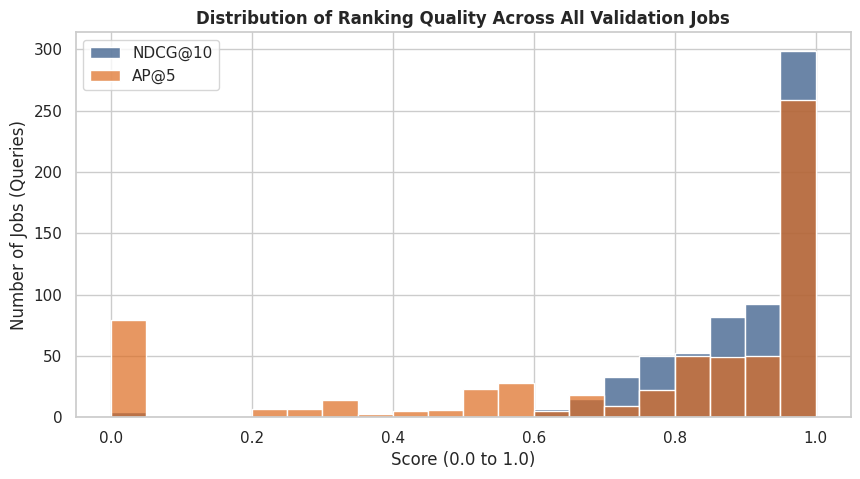

In [141]:
# --- 4.3 Global Evaluation (Mean Metrics) ---

# Calculate metrics for every individual job
evaluation_results = []
for job_id, group in ranked_val.groupby('job_id'):
    labels = group['relevance_label'].values
    ndcg_10 = calculate_ndcg(labels, k=10)
    ap_5 = calculate_ap_at_5(labels)
    
    evaluation_results.append({'job_id': job_id, 'NDCG@10': ndcg_10, 'AP@5': ap_5})

eval_df = pd.DataFrame(evaluation_results)

# Calculate the Global Means
mean_ndcg = eval_df['NDCG@10'].mean()
map_5 = eval_df['AP@5'].mean()

print("="*40)
print(f"Final Validation Metrics (Custom Calculation)")
print(f"Mean NDCG@10: {mean_ndcg:.4f}")
print(f"Mean AP@5 (MAP@5): {map_5:.4f}")
print("="*40)

# Visualizing the performance distribution across all queries
plt.figure(figsize=(10, 5))
sns.histplot(eval_df['NDCG@10'], bins=20, color='#2c5282', alpha=0.7, label='NDCG@10')
sns.histplot(eval_df['AP@5'], bins=20, color='#dd6b20', alpha=0.7, label='AP@5')
plt.title('Distribution of Ranking Quality Across All Validation Jobs', fontweight='bold')
plt.xlabel('Score (0.0 to 1.0)')
plt.ylabel('Number of Jobs (Queries)')
plt.legend()

# Save for the report
plt.savefig('latex/assets/images/06_evaluation_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

<a id="submission"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">5. Prediction & Final Submission</h2>

<div class="alert alert-success" style="background-color: #f0fff4; border-left: 4px solid #38a169; color: #276749;">
    <strong>✅ Methodology:</strong> In this final phase, we apply our optimized LightGBM Ranker to the unseen `application_test.csv` dataset. The model generates continuous margin scores (log-odds) representing the relative fit of each candidate. The predictions are mapped back to their original `application_id`s and exported directly to a CSV file while strictly preserving the original row indices to comply with the Quera auto-grader requirements.
</div>

### Step 5.1: Generating Test Predictions

In [142]:
# --- 5.1 Generate Final Predictions ---

# 1. Ensure the test set features exactly match the training features
X_test = test_full[features]

print(f"Scoring {X_test.shape[0]} unseen applications...")

# 2. Predict the continuous scores using the best model from Phase 3
# Note: best_model was saved in our hyperparameter tuning loop
test_full['predicted_score'] = best_model.predict(X_test)

print("Scoring complete! Sample of raw predicted margins:")
display(test_full[['application_id', 'job_id', 'predicted_score']].head())

Scoring 52700 unseen applications...
Scoring complete! Sample of raw predicted margins:


,application_id,job_id,predicted_score
0,1,1,0.541218
1,2,1,-0.345420
2,3,1,-3.400055
3,4,1,0.082171
4,5,1,0.471905


### Step 5.2: Formatting & Exporting the Submission

In [143]:
# --- 5.2 Formatting & Exporting Submission (UPDATED) ---

# 1. Isolate the required columns and rename them to match Quera's exact format
submission_df = test_full[['application_id', 'predicted_score']].copy()

# Rename to match the expected submission format exactly
submission_df = submission_df.rename(columns={
    'predicted_score': 'score'
})

# 2. Save to CSV without the index, preserving original row order in the current directory
submission_filename = 'task3_predictions_submit.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Final Submission File Saved: {submission_filename}")

Final Submission File Saved: task3_predictions_submit.csv
